# Tarea para el Hogar 05

##  1. Overfitting the Public Leaderboard

Leer  https://medium.com/hmif-itb/overfitting-the-leaderboard-da25172ac62e
( 8 minutos )

## 2. Hiperparámetros del LightGBM

Los objetivos de esta tarea son:


*   Aumentar la rentabilidad de la campaña de marketing de retención proactiva de clientes.
*   Generar un mejor modelo optimizando sus hiperparámetros
*   Conceptual : investigar los mas relevantes hiperparámetros de LightGBM
*   Familiarizarse con el uso de máquinas virtuales de Google Colab
*   Ver un pipeline completo de optimización de hiperparámetros y puesta en producción

LightGBM cuenta con mas de 60 hiperparámetros, siendo posible utilizar 40 al mismo tiempo, aunque no razonable.
<br> La documentación oficial de los hiperparámetros de LightGBM es  https://lightgbm.readthedocs.io/en/latest/Parameters.html#core-parameters


Se lo alerta sobre que una Optimizacion sw Hiperparámetros lleva varias horas de corrida, y usted deberá correr VARIAS optimizaciones para descubrir cuales parámetros conviene optimizar.


Es necesario investigar cuales son los hiperparámetros de LightGBM que vale la pena optimizar, ya que los realmente utiles son apenas un reducido subconjunto.
<br>Usted deberá investigar cuales son los hiperparámetros mas relevantes de LightGBM, su primer alternativa es preguntándole a su amigo con capacidades especiales ChatGPT o sus endogámicos familiares Claude, DeepSeek, Gemini, Grok, etc
<br> La segunda alternativa es la propia documentación de LightGBM  https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html


Adicionalmente podra buscar información como la que proveen esta diminuta muestra aleatoria de artículos ligeros:
* https://machinelearningmastery.com/light-gradient-boosted-machine-lightgbm-ensemble/
*  https://medium.com/@sarahzouinina/a-deep-dive-into-lightgbm-how-to-choose-and-tune-parameters-7c584945842e
*  https://www.kaggle.com/code/somang1418/tuning-hyperparameters-under-10-minutes-lgbm
*  https://towardsdatascience.com/beginners-guide-to-the-must-know-lightgbm-hyperparameters-a0005a812702/


<br>  La muestra anterior se brinda a modo de ejemplo, usted deberá buscar muuuuchas  fuentes adicionales de información
<br> Tenga presente que LightGBM es el estado del arte en modelado predictivo para datasets estructurado, que son el 90% del trabajo del 95% de los Data Scientists en Argentina.

El desafío de esta tarea es:
* Qué hiperparparámetros conviene optimizar?  Las recomendaciones de los artículos ligeros es siempre sensata?  Sus autores realmente hicieron experimentos o son siemplemente escritores de entretenimiento carente de base científica?
* Elegidos los hiperparámetros, cual es el  <desde, hasta> que se debe utilizar en la Bayesian Optimization ?
* Realmente vale la pena optimizar 10 o 16 hiperparámetros al mismo tiempo ?  No resulta contraproducente una búsqueda en un espacio de tal alta dimensionalidad ?

#### 2.1  Seteo del ambiente local


Esta parte se debe correr con un kernel de R local.
<br>En Jupyter, seleccionar el kernel **R** antes de ejecutar el notebook.


Los archivos persistentes quedan en el repo local: datasets en `datasets/` y resultados en `exp/`.


In [1]:
# Seteo local: resuelve el root del repo (funciona desde raiz, src/ensembles o exp/<exp>)
resolve_root <- function(start = getwd()) {
  d <- normalizePath(start, mustWork = TRUE)
  for (i in seq_len(8)) {
    if (dir.exists(file.path(d, "datasets"))) return(d)
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }
  stop("No encuentro la carpeta datasets/ subiendo desde: ", start)
}

ROOT_DIR <- resolve_root()
DATA_DIR <- file.path(ROOT_DIR, "datasets")
EXP_DIR <- file.path(ROOT_DIR, "exp")
KAGGLE_JSON <- file.path(ROOT_DIR, "kaggle.json")


Para correr localmente, el dataset debe estar en `datasets/` dentro del repo.

<br>Si se va a subir a Kaggle, copiar `kaggle.json` a la raiz del repo antes de correr la siguiente celda. La celda lo instala en `~/.kaggle/kaggle.json` con permisos correctos.


In [2]:
dir.create(DATA_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(EXP_DIR, recursive = TRUE, showWarnings = FALSE)

dataset_local <- file.path(DATA_DIR, "dataset_pequeno.csv")
if (!file.exists(dataset_local)) {
  stop("No encuentro el dataset en: ", dataset_local)
}

if (file.exists(KAGGLE_JSON)) {
  kaggle_dir <- path.expand("~/.kaggle")
  dir.create(kaggle_dir, recursive = TRUE, showWarnings = FALSE)
  file.copy(KAGGLE_JSON, file.path(kaggle_dir, "kaggle.json"), overwrite = TRUE)
  Sys.chmod(file.path(kaggle_dir, "kaggle.json"), mode = "0600")
} else {
  message("No encontre kaggle.json en la raiz del repo. Solo es necesario para hacer submit a Kaggle.")
}


### 2.2 Optimizacion Hiperparámetros

Esta parte se corre en R (mismo kernel local). No hace falta cambiar de runtime de Colab.


### 2.2.1 Inicio

limpio el ambiente de R

In [3]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Fri Aug 14 18:01:42 2026"

In [4]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,676829,36.2,1489770,79.6,NA,1489770,79.6
Vcells,1259256,9.7,8388608,64.0,49152,2014427,15.4


### 2.2.2 Carga de Librerias

In [5]:
# cargo las librerias que necesito
require("data.table")
require("parallel")

if( !require("primes") ) install.packages("primes")
require("primes")

if( !require("utils") ) install.packages("utils")
require("utils")

if( !require("rlist") ) install.packages("rlist")
require("rlist")

if( !require("yaml")) install.packages("yaml")
require("yaml")

if( !require("lightgbm") ) install.packages("lightgbm")
require("lightgbm")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: parallel

Loading required package: primes

Loading required package: rlist

Loading required package: yaml

Loading required package: lightgbm

Warning message:
“package ‘lightgbm’ was built under R version 4.6.1”


### 2.2.3 Definicion de Parametros

aqui debe cargar SU semilla primigenia
<br>recuerde cambiar el numero de experimento en cada corrida nueva

In [6]:
PARAM <- list()
PARAM$experimento <- 5957

PARAM$semilla_primigenia <- 300089

In [7]:
PARAM$kaggle$competencia <- "data-mining-inicial-2026-b"
PARAM$kaggle$cortes <- seq(9000, 12000, by= 500)

In [8]:
# un undersampling de 0.1  toma solo el 10% de los CONTINUA
# undersampling de 1.0  implica tomar TODOS los datos

PARAM$trainingstrategy$undersampling <- 0.7

In [9]:
# Parametros LightGBM

PARAM$hyperparametertuning$xval_folds <- 5

# parametros fijos del LightGBM que se pisaran con la parte variable de la BO
PARAM$lgbm$param_fijos <-  list(
  boosting= "gbdt", # puede ir  dart  , ni pruebe random_forest
  objective= "binary",
  metric= "auc",
  first_metric_only= FALSE,
  boost_from_average= TRUE,
  feature_pre_filter= FALSE,
  force_row_wise= TRUE, # para reducir warnings
  verbosity= -100,

  seed= PARAM$semilla_primigenia,

  max_depth= -1L, # -1 significa no limitar,  por ahora lo dejo fijo
  min_gain_to_split= 0, # min_gain_to_split >= 0
  min_sum_hessian_in_leaf= 0.001, #  min_sum_hessian_in_leaf >= 0.0
  lambda_l1= 0.0, # lambda_l1 >= 0.0
  lambda_l2= 0.0, # lambda_l2 >= 0.0
  max_bin= 31L, # lo debo dejar fijo, no participa de la BO

  bagging_fraction= 1.0, # 0.0 < bagging_fraction <= 1.0
  bagging_freq= 1L, # bagging solo es efectivo con bagging_freq > 0
  pos_bagging_fraction= 1.0, # 0.0 < pos_bagging_fraction <= 1.0
  neg_bagging_fraction= 1.0, # 0.0 < neg_bagging_fraction <= 1.0
  is_unbalance= FALSE, #
  scale_pos_weight= 1.0, # scale_pos_weight > 0.0

  data_sample_strategy= "goss", # replica HT5954 (mejor AUC CV y Kaggle)
  top_rate= 0.4, # solo activo con GOSS
  other_rate= 0.1, # solo activo con GOSS

  drop_rate= 0.1, # 0.0 < neg_bagging_fraction <= 1.0
  max_drop= 50, # <=0 means no limit
  skip_drop= 0.5, # 0.0 <= skip_drop <= 1.0

  extra_trees= FALSE,

  num_iterations= 100,
  learning_rate= 0.05,  # >=0
  feature_fraction= 1.0, # 0 < ff <= 1.0
  num_leaves= 20, # integer >= 2
  min_data_in_leaf= 20, # integer >= 0

  # paralelismo de la grilla: cada worker entrena con FEW threads,
  #  el paralelismo REAL lo da mclapply sobre las filas de la grilla
  num_threads= 2


)


### 2.2.4  Preprocesamiento

In [10]:
# carpeta de trabajo (re-resuelve paths por si hubo rm() arriba)
resolve_root <- function(start = getwd()) {
  d <- normalizePath(start, mustWork = TRUE)
  for (i in seq_len(8)) {
    if (dir.exists(file.path(d, "datasets"))) return(d)
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }
  stop("No encuentro la carpeta datasets/ subiendo desde: ", start)
}

ROOT_DIR <- resolve_root()
DATA_DIR <- file.path(ROOT_DIR, "datasets")
EXP_DIR <- file.path(ROOT_DIR, "exp")

dir.create(EXP_DIR, recursive = TRUE, showWarnings = FALSE)
experimento_folder <- paste0("HT", PARAM$experimento)
dir.create(file.path(EXP_DIR, experimento_folder), recursive = TRUE, showWarnings = FALSE)
setwd(file.path(EXP_DIR, experimento_folder))


In [11]:
# lectura del dataset
dataset <- fread(file.path(DATA_DIR, "dataset_pequeno.csv"))

In [12]:
dataset_train <- dataset[foto_mes %in% c(202107)]

In [13]:
# paso la clase a binaria que tome valores {0,1}  enteros
#  BAJA+1 y BAJA+2  son  1,   CONTINUA es 0

dataset_train[,
  clase01 := ifelse(clase_ternaria %in% c("BAJA+2","BAJA+1"), 1L, 0L)
]

In [14]:
# defino los datos que forma parte del training
# aqui se hace el undersampling de los CONTINUA
# notar que para esto utilizo la SEGUNDA semilla

set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
dataset_train[, azar := runif(nrow(dataset_train))]
dataset_train[, training := 0L]

dataset_train[
  foto_mes %in% c(202107) &
    (azar <= PARAM$trainingstrategy$undersampling | clase_ternaria %in% c("BAJA+1", "BAJA+2")),
  training := 1L
]

In [15]:
# los campos que se van a utilizar

campos_buenos <- setdiff(
  colnames(dataset_train),
  c("clase_ternaria", "clase01", "azar", "training")
)

In [16]:
# dejo los datos en el formato que necesita LightGBM

dtrain <- lgb.Dataset(
  data= data.matrix(dataset_train[training == 1L, campos_buenos, with= FALSE]),
  label= dataset_train[training == 1L, clase01],
  free_raw_data= FALSE
)

nrow(dtrain)
ncol(dtrain)

[1] 115727

[1] 154

2.2.5 Configuracion del Grid Search

In [17]:
# En el argumento x llegan los parametros de LightGBM (lista NOMBRADA).
#  IMPORTANTE: as.list(...) / as.list(tb_nueva[i]), NUNCA list(.SD) sin nombres.
#  Devuelve list(AUC, best_iter).
#
# Fork-safe: reconstruye lgb.Dataset DENTRO del worker. Reusar un dtrain
#  creado en el padre con mclapply (fork) suele romper LightGBM en macOS.

Estimar_AUC_lightgbm <- function(x) { # nolint

  if (is.data.frame(x)) x <- as.list(x)
  if (length(x) == 1L && is.data.frame(x[[1]])) x <- as.list(x[[1]])
  # scalars (data.table as.list a veces deja length>1)
  x <- lapply(x, function(z) if (length(z) == 1L) z[[1]] else z)

  es_rounds <- if (is.null(x$early_stopping_rounds)) 100L else as.integer(x$early_stopping_rounds)
  x$early_stopping_rounds <- NULL  # es argumento de lgb.cv, no param de LightGBM
  param_completo <- modifyList(PARAM$lgbm$param_fijos, x)
  if (!is.null(x$seed)) set.seed(x$seed, kind = "L'Ecuyer-CMRG")

  # dataset local al proceso (evita handles invalidos post-fork)
  dtrain_local <- lgb.Dataset(
    data = data.matrix(dataset_train[training == 1L, campos_buenos, with = FALSE]),
    label = dataset_train[training == 1L, clase01],
    free_raw_data = TRUE
  )

  modelocv <- lgb.cv(
    data = dtrain_local,
    nfold = PARAM$hyperparametertuning$xval_folds,
    stratified = TRUE,
    param = param_completo,
    early_stopping_rounds = es_rounds
  )

  AUC <- modelocv$best_score
  best_iter <- modelocv$best_iter

  rm(modelocv, dtrain_local)
  gc(full = TRUE, verbose = FALSE)

  message(format(Sys.time(), "%a %b %d %X %Y  "),
    toString(x),
    " AUC ", AUC,
    " best_iter ", best_iter
  )

  list(AUC = as.numeric(AUC), best_iter = as.integer(best_iter))
}


In [18]:
# GRID - EXPERIMENTO run 3 (r3): path_smooth sobre el winner de HT5956
# ---------------------------------------------------------------------------
# Baseline: winner HT5956 = min_data=200, max_depth=12, leaves=255,
#  ff=0.6, l2=300, GOSS top_rate=0.4/other_rate=0.1, AUC CV 0.932910.
#  DECISION: lr 0.005 -> 0.02 (delta CV es ruido, 4x mas rapido:
#  ~2.6k iters vs ~10k). lr baja en el futuro SOLO si el LB lo pide.
# Cambios de este run (rastreables uno a uno contra el baseline):
#   - undersampling 0.5 -> 0.7  (PARAM$trainingstrategy; mas CONTINUA en el
#     training; literatura de churn: mejor para metricas de lift/top-k)
#   - path_smooth: 0 (control) | 0.5 | 1.0 | 2.0
#     (regulariza hojas con pocas filas, el problema de los ~150 positivos;
#     requiere min_data_in_leaf >= 2; LightGBM >= 4.4)
#   - num_leaves: 63 | 127 | 255. Con min_data=200 y ~42k filas (us 0.7)
#     el max teorico de hojas es ~42k/200 = 210 -> 255 lo excede, 127 no.
#   - GOSS se mantiene ON (data_sample_strategy="goss" de param_fijos)
# 12 filas = path_smooth(4) x num_leaves(3)
tb_nueva <- CJ(
  path_smooth = c(0, 0.5, 1.0, 2.0),
  num_leaves = c(63L, 127L, 255L)
)
tb_nueva[, `:=`(
  learning_rate = 0.02,
  min_data_in_leaf = 200L,
  num_iterations = 3000L,          # techo MAX 3000; ES fija best_iter
  early_stopping_rounds = 100L,    # escala ~1/lr
  num_leaves = num_leaves,
  max_depth = 12L,
  feature_fraction = 0.6,
  bagging_fraction = 1.0,
  bagging_freq = 1L,
  lambda_l1 = 0,
  lambda_l2 = 300,
  top_rate = 0.4,
  other_rate = 0.1
)]

message("filas en grilla: ", nrow(tb_nueva))
stopifnot(
  all(tb_nueva$bagging_fraction > 0 & tb_nueva$bagging_fraction <= 1),
  all(tb_nueva$feature_fraction > 0 & tb_nueva$feature_fraction <= 1)
)
tb_nueva

filas en grilla: 12



path_smooth,num_leaves,learning_rate,min_data_in_leaf,num_iterations,early_stopping_rounds,max_depth,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2,top_rate,other_rate
<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
0.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
0.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
0.5,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
0.5,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
0.5,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
1.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
1.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1
1.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1


In [19]:
nrow(tb_nueva)

[1] 12

In [20]:
# registro a registro calculo la AUC, EN PARALELO
#  - mclapply (fork en macOS). LightGBM: preferir num_threads chico en params.
#  - set.seed(semilla + i) por fila (forks heredan el mismo RNG si no).
#  - Si un worker falla, reventamos con el mensaje REAL (no "subscript out of bounds").

mc_cores_use <- min(9L, max(1L, parallel::detectCores() - 4L))
message("mclapply con mc.cores=", mc_cores_use,
        " | num_threads por modelo=", PARAM$lgbm$param_fijos$num_threads)

res <- parallel::mclapply(seq_len(nrow(tb_nueva)), function(i) {
  set.seed(PARAM$semilla_primigenia + i, kind = "L'Ecuyer-CMRG")
  params_i <- as.list(tb_nueva[i])
  # quitar columnas de resultado si re-corres la celda
  params_i$AUC <- NULL
  params_i$best_iter <- NULL
  tryCatch(
    Estimar_AUC_lightgbm(params_i),
    error = function(e) {
      list(.error = conditionMessage(e), .row = i)
    }
  )
}, mc.cores = mc_cores_use)

# Diagnosticar fallos de workers ANTES de armar la tabla
failed <- vapply(res, function(z) !is.null(z$.error), logical(1))
if (any(failed)) {
  message("Fallaron ", sum(failed), " / ", length(res), " workers. Ejemplos:")
  for (z in res[failed][seq_len(min(3L, sum(failed)))]) {
    message("  fila ", z$.row, ": ", z$.error)
  }
  stop(
    "mclapply: errores en workers (ver mensajes arriba). ",
    "Causa tipica: bagging_fraction/feature_fraction fuera de (0,1], ",
    "o LightGBM+fork. Proba mc.cores=1 para aislar."
  )
}

tb_nueva[, AUC := vapply(res, function(z) z$AUC, numeric(1))]
tb_nueva[, best_iter := vapply(res, function(z) z$best_iter, integer(1))]
tb_nueva


mclapply con mc.cores=9 | num_threads por modelo=2



path_smooth,num_leaves,learning_rate,min_data_in_leaf,num_iterations,early_stopping_rounds,max_depth,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2,top_rate,other_rate,AUC,best_iter
<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
0.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9323958,2182
0.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9322624,1959
0.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9319480,1863
0.5,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9324414,2098
0.5,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9312929,1825
0.5,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9328769,2173
1.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9329177,2136
1.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9321341,1879
1.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9324773,2038


In [21]:
# veo que tiene la tabla DESPUES de procesar
tb_nueva

path_smooth,num_leaves,learning_rate,min_data_in_leaf,num_iterations,early_stopping_rounds,max_depth,feature_fraction,bagging_fraction,bagging_freq,lambda_l1,lambda_l2,top_rate,other_rate,AUC,best_iter
<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
0.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9323958,2182
0.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9322624,1959
0.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9319480,1863
0.5,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9324414,2098
0.5,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9312929,1825
0.5,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9328769,2173
1.0,63,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9329177,2136
1.0,127,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9321341,1879
1.0,255,0.02,200,3000,100,12,0.6,1,1,0,300,0.4,0.1,0.9324773,2038


In [22]:
# escribo la grilla completa (overwrite: un HT limpio por experimento)
fwrite(tb_nueva,
  file = "tb_grid_serach_01.txt",
  sep = "\t",
  append = FALSE
)


In [23]:
setorder(tb_nueva, -AUC)
tb_nueva[, .(lambda_l1, min_data_in_leaf, lambda_l2, num_leaves,
  feature_fraction, AUC, best_iter)]

PARAM$out$lgbm$AUC <- tb_nueva[1, AUC]
# best_iter: el modelo final NO hace early stopping (no tiene valids),
#  asi que se entrena con num_iterations = best_iter del ganador
PARAM$out$lgbm$best_iter <- tb_nueva[1, best_iter]
PARAM$out$lgbm$mejores_hiperparametros <- as.list(tb_nueva[1])
PARAM$out$lgbm$mejores_hiperparametros$AUC <- NULL
PARAM$out$lgbm$mejores_hiperparametros$best_iter <- NULL
PARAM$out$lgbm$mejores_hiperparametros$num_iterations <- tb_nueva[1, best_iter]
# early_stopping_rounds NO es parametro de LightGBM; va por argumento
PARAM$out$lgbm$mejores_hiperparametros$early_stopping_rounds <- NULL
PARAM$out$lgbm$mejores_hiperparametros


lambda_l1,min_data_in_leaf,lambda_l2,num_leaves,feature_fraction,AUC,best_iter
<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>
0,200,300,63,0.6,0.9329177,2136
0,200,300,255,0.6,0.9328769,2173
0,200,300,255,0.6,0.9328284,2165
0,200,300,255,0.6,0.9324773,2038
0,200,300,63,0.6,0.9324414,2098
0,200,300,63,0.6,0.9323958,2182
0,200,300,63,0.6,0.9323644,2169
0,200,300,127,0.6,0.9322624,1959
0,200,300,127,0.6,0.9322116,1879


$path_smooth
[1] 1

$num_leaves
[1] 63

$learning_rate
[1] 0.02

$min_data_in_leaf
[1] 200

$num_iterations
[1] 2136

$max_depth
[1] 12

$feature_fraction
[1] 0.6

$bagging_fraction
[1] 1

$bagging_freq
[1] 1

$lambda_l1
[1] 0

$lambda_l2
[1] 300

$top_rate
[1] 0.4

$other_rate
[1] 0.1

In [24]:
# ---------------------------------------------------------------------------
# Top 5 + marginales: lambda_l1 vs min_data_in_leaf
# Cambios de AUC < ~0.0004 suelen ser ruido de la CV de 5 folds
# min_data en escala GRILLA; en full sera ~2x (undersampling 0.5)
# ---------------------------------------------------------------------------
tb_nueva[1:5, .(lambda_l1, min_data_in_leaf, AUC, best_iter)]

message("--- marginal lambda_l1 ---")
print(tb_nueva[, .(mean_AUC = mean(AUC), max_AUC = max(AUC),
                   mean_best_iter = mean(best_iter), n = .N),
               by = lambda_l1][order(-mean_AUC)])

message("--- marginal min_data_in_leaf (escala grilla) ---")
print(tb_nueva[, .(
  mean_AUC = mean(AUC), max_AUC = max(AUC),
  mean_best_iter = mean(best_iter), n = .N,
  min_data_full_equiv = round(min_data_in_leaf /
                                PARAM$trainingstrategy$undersampling)
), by = min_data_in_leaf][order(-mean_AUC)])

message("--- heatmap lambda_l1 x min_data (max AUC) ---")
print(dcast(tb_nueva, lambda_l1 ~ min_data_in_leaf, value.var = "AUC",
            fun.aggregate = max))


lambda_l1,min_data_in_leaf,AUC,best_iter
<dbl>,<int>,<dbl>,<int>
0,200,0.9329177,2136
0,200,0.9328769,2173
0,200,0.9328284,2165
0,200,0.9324773,2038
0,200,0.9324414,2098


--- marginal lambda_l1 ---



   lambda_l1  mean_AUC   max_AUC mean_best_iter     n
       <num>     <num>     <num>          <num> <int>
1:         0 0.9323459 0.9329177         2030.5    12


--- marginal min_data_in_leaf (escala grilla) ---



   min_data_in_leaf  mean_AUC   max_AUC mean_best_iter     n
              <int>     <num>     <num>          <num> <int>
1:              200 0.9323459 0.9329177         2030.5    12
   min_data_full_equiv
                 <num>
1:                 286


--- heatmap lambda_l1 x min_data (max AUC) ---



Key: <lambda_l1>
   lambda_l1       200
       <num>     <num>
1:         0 0.9329177


In [25]:
PARAM

$experimento
[1] 5957

$semilla_primigenia
[1] 300089

$kaggle
$kaggle$competencia
[1] "data-mining-inicial-2026-b"

$kaggle$cortes
[1]  9000  9500 10000 10500 11000 11500 12000


$trainingstrategy
$trainingstrategy$undersampling
[1] 0.7


$hyperparametertuning
$hyperparametertuning$xval_folds
[1] 5


$lgbm
$lgbm$param_fijos
$lgbm$param_fijos$boosting
[1] "gbdt"

$lgbm$param_fijos$objective
[1] "binary"

$lgbm$param_fijos$metric
[1] "auc"

$lgbm$param_fijos$first_metric_only
[1] FALSE

$lgbm$param_fijos$boost_from_average
[1] TRUE

$lgbm$param_fijos$feature_pre_filter
[1] FALSE

$lgbm$param_fijos$force_row_wise
[1] TRUE

$lgbm$param_fijos$verbosity
[1] -100

$lgbm$param_fijos$seed
[1] 300089

$lgbm$param_fijos$max_depth
[1] -1

$lgbm$param_fijos$min_gain_to_split
[1] 0

$lgbm$param_fijos$min_sum_hessian_in_leaf
[1] 0.001

$lgbm$param_fijos$lambda_l1
[1] 0

$lgbm$param_fijos$lambda_l2
[1] 0

$lgbm$param_fijos$max_bin
[1] 31

$lgbm$param_fijos$bagging_fraction
[1] 1

$lgbm$param_fijos$bagging_freq
[1] 1

$lgbm$param_fijos$pos_bagging_fraction
[1] 1

$lgbm$param_fijos$neg_bagging_fraction
[1] 1

$lgbm$param_fijos$is_unbalance
[1] FALSE

$lgbm$param_fijos$scale_pos_weight
[1] 1

$lgbm$param_fijos$data_sample_strategy
[1] "goss"

$lgbm$param_fijos$top_rate
[1] 0.4

$lgbm$param_fijos$other_rate
[1] 0.1

$lgbm$param_fijos$drop_rate
[1] 0.1

$lgbm$param_fijos$max_drop
[1] 50

$lgbm$param_fijos$skip_drop
[1] 0.5

$lgbm$param_fijos$extra_trees
[1] FALSE

$lgbm$param_fijos$num_iterations
[1] 100

$lgbm$param_fijos$learning_rate
[1] 0.05

$lgbm$param_fijos$feature_fraction
[1] 1

$lgbm$param_fijos$num_leaves
[1] 20

$lgbm$param_fijos$min_data_in_leaf
[1] 20

$lgbm$param_fijos$num_threads
[1] 2



$out
$out$lgbm
$out$lgbm$AUC
[1] 0.9329177

$out$lgbm$best_iter
[1] 2136

$out$lgbm$mejores_hiperparametros
$out$lgbm$mejores_hiperparametros$path_smooth
[1] 1

$out$lgbm$mejores_hiperparametros$num_leaves
[1] 63

$out$lgbm$mejores_hiperparametros$learning_rate
[1] 0.02

$out$lgbm$mejores_hiperparametros$min_data_in_leaf
[1] 200

$out$lgbm$mejores_hiperparametros$num_iterations
[1] 2136

$out$lgbm$mejores_hiperparametros$max_depth
[1] 12

$out$lgbm$mejores_hiperparametros$feature_fraction
[1] 0.6

$out$lgbm$mejores_hiperparametros$bagging_fraction
[1] 1

$out$lgbm$mejores_hiperparametros$bagging_freq
[1] 1

$out$lgbm$mejores_hiperparametros$lambda_l1
[1] 0

$out$lgbm$mejores_hiperparametros$lambda_l2
[1] 300

$out$lgbm$mejores_hiperparametros$top_rate
[1] 0.4

$out$lgbm$mejores_hiperparametros$other_rate
[1] 0.1

In [26]:
write_yaml( PARAM, file="PARAM.yml")

[1] 379699 145307 962789 846401 243989
[1] 379699 145307 962789 846401 243989


Curva diagnostico: num_iterations techo=2000 | early_stopping_rounds=100 | hiperparams base: lr=0.02 leaves=63 min_data=200

semilla 379699 | best_iter= 1933 | iters corridas= 2000 | AUC valid max= 0.928

semilla 145307 | best_iter= 1719 | iters corridas= 1819 | AUC valid max= 0.93639

semilla 962789 | best_iter= 1551 | iters corridas= 1651 | AUC valid max= 0.93802

semilla 846401 | best_iter= 2000 | iters corridas= 2000 | AUC valid max= 0.92699

semilla 243989 | best_iter= 1941 | iters corridas= 2000 | AUC valid max= 0.93378



semilla,best_iter,auc_valid_best,n_iters_run
<int>,<int>,<dbl>,<int>
379699,1933,0.9280020,2000
145307,1719,0.9363938,1819
962789,1551,0.9380196,1651
846401,2000,0.9269939,2000
243989,1941,0.9337789,2000


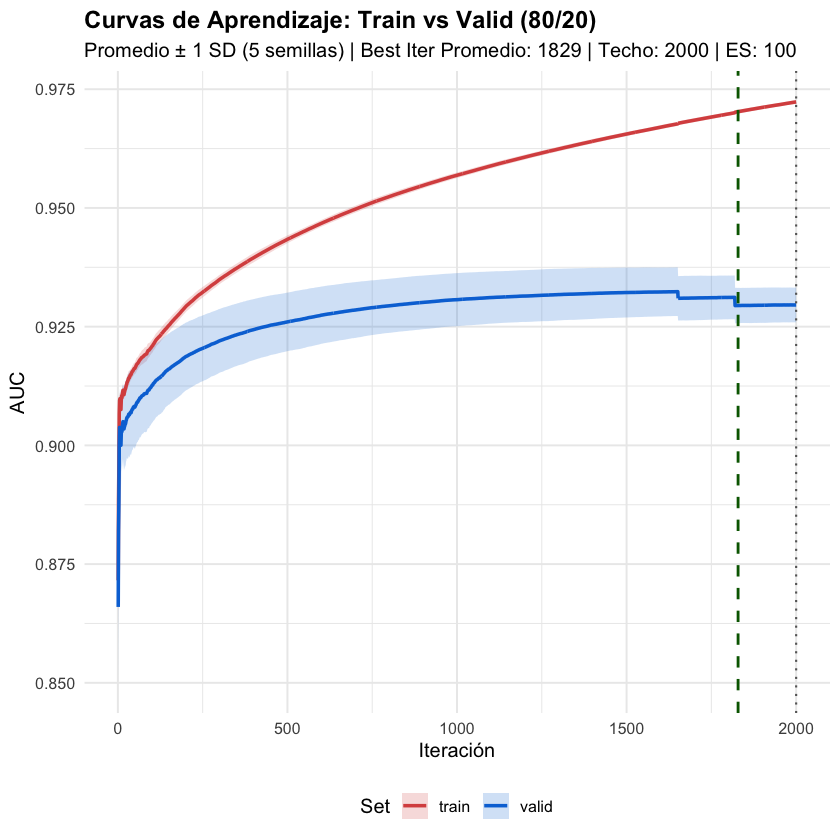

In [27]:
# genero numeros primos
primos <- generate_primes(min = 100000, max = 1000000)

set.seed(300089) # inicializo con mi primer semilla
# me quedo con por ejemplo 20 primos al azar
semillas <- sample(primos, 5)
print(semillas)

library(data.table)
library(ggplot2)
library(lightgbm)

# ---------------------------------------------------------------------------
# CURVAS train/valid del combo ganador (split 80/20) x SEMILLAS (ggplot2)
# ---------------------------------------------------------------------------

param_curva <- modifyList(
  PARAM$lgbm$param_fijos,
  PARAM$out$lgbm$mejores_hiperparametros
)

library(data.table)
library(ggplot2)
library(lightgbm)

set.seed(PARAM$semilla_primigenia) # misma semilla base del curso
# 5 semillas: con techo 3000, 100 semillas seria demasiado lento
PARAM$semillas <- semillas
print(PARAM$semillas)

param_curva <- modifyList(
  PARAM$lgbm$param_fijos,
  PARAM$out$lgbm$mejores_hiperparametros
)

# Techo del diagnostico (independiente del best_iter de la grilla)
PARAM_CURVA_TECHOS <- 2000   # max 2000 iters para el plot
PARAM_CURVA_ES     <- 100
param_curva$num_iterations <- PARAM_CURVA_TECHOS

message(
  "Curva diagnostico: num_iterations techo=", PARAM_CURVA_TECHOS,
  " | early_stopping_rounds=", PARAM_CURVA_ES,
  " | hiperparams base: lr=", param_curva$learning_rate,
  " leaves=", param_curva$num_leaves,
  " min_data=", param_curva$min_data_in_leaf
)

# 1. MATRIZ Y VECTOR FUERA DEL LOOP (Optimización de velocidad y RAM)
X_mat <- data.matrix(dataset_train[, campos_buenos, with = FALSE])

# as.numeric() fuerza un vector atómico 1D tipo 'double' para LightGBM
y_vec <- as.numeric(dataset_train[, clase01])

n_samples  <- nrow(X_mat)
train_size <- floor(0.8 * n_samples)

evals_list    <- vector("list", length(PARAM$semillas))
resumen_curva <- vector("list", length(PARAM$semillas))

# 2. LOOP DE ENTRENAMIENTO POR SEMILLA
for (isem in seq_along(PARAM$semillas)) {

  semilla_actual <- PARAM$semillas[isem]
  set.seed(semilla_actual, kind = "L'Ecuyer-CMRG")
  idx <- sample.int(n_samples, train_size)

  # Crear datasets con alineación de bins (reference = dtr)
  dtr <- lgb.Dataset(
    data  = X_mat[idx, , drop = FALSE],
    label = y_vec[idx]
  )
  dva <- lgb.Dataset(
    data      = X_mat[-idx, , drop = FALSE],
    label     = y_vec[-idx],
    reference = dtr
  )

  # Entrenar modelo (techo alto; ES decide best_iter)
  modelo_curva <- lgb.train(
    data                  = dtr,
    valids                = list(valid = dva, train = dtr),
    param                 = param_curva,
    early_stopping_rounds = PARAM_CURVA_ES
  )

  evals     <- modelo_curva$record_evals
  auc_train <- unlist(evals$train$auc)
  auc_valid <- unlist(evals$valid$auc)

  # Guardar métricas por iteración
  evals_list[[isem]] <- data.table(
    semilla = semilla_actual,
    iter    = seq_along(auc_train),
    train   = auc_train,
    valid   = auc_valid
  )

  # Resumen de resultados por semilla
  resumen_curva[[isem]] <- data.table(
    semilla        = semilla_actual,
    best_iter      = modelo_curva$best_iter,
    auc_valid_best = max(auc_valid),
    n_iters_run    = length(auc_valid)
  )

  message("semilla ", semilla_actual,
          " | best_iter= ", modelo_curva$best_iter,
          " | iters corridas= ", length(auc_valid),
          " | AUC valid max= ", round(max(auc_valid), 5))

  rm(dtr, dva, modelo_curva)
  gc(full = TRUE, verbose = FALSE)
}

# 3. PROCESAR DATOS Y AGREGAR ESTADÍSTICAS
dt_evals <- rbindlist(evals_list)

dt_long <- melt(
  dt_evals,
  id.vars       = c("semilla", "iter"),
  variable.name = "split",
  value.name    = "auc"
)

# Calcular Promedio y Desviación Estándar por iteración y split
# (solo promedia semillas que llegaron a esa iter; al final el n baja)
dt_summary <- dt_long[, .(
  mean_auc = mean(auc, na.rm = TRUE),
  sd_auc   = sd(auc, na.rm = TRUE),
  n        = .N
), by = .(iter, split)]

dt_summary[, upper := mean_auc + sd_auc]
dt_summary[, lower := mean_auc - sd_auc]

resumen_curva  <- rbindlist(resumen_curva)
mean_best_iter <- mean(resumen_curva$best_iter)
max_iter_plot  <- max(dt_summary$iter)

# 4. GRAFICAR CON GGPLOT2
p <- ggplot(dt_summary, aes(x = iter, y = mean_auc, color = split, fill = split)) +
  # Sombra de desvío estándar (± 1 SD)
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.2, color = NA) +
  # Línea promedio de las métricas
  geom_line(linewidth = 1) +
  # Línea vertical indicando el best_iter promedio
  geom_vline(
    xintercept = mean_best_iter,
    linetype   = "dashed",
    color      = "darkgreen",
    linewidth  = 0.8
  ) +
  # Techo del diagnostico (referencia visual)
  geom_vline(
    xintercept = PARAM_CURVA_TECHOS,
    linetype   = "dotted",
    color      = "gray40",
    linewidth  = 0.6
  ) +
  scale_color_manual(values = c("train" = "#D9534F", "valid" = "#0275D8")) +
  scale_fill_manual(values  = c("train" = "#D9534F", "valid" = "#0275D8")) +
  scale_x_continuous(
    limits = c(1, max(max_iter_plot, mean_best_iter, 100)),
    breaks = pretty
  ) +
  labs(
    title    = "Curvas de Aprendizaje: Train vs Valid (80/20)",
    subtitle = sprintf(
      "Promedio ± 1 SD (%d semillas) | Best Iter Promedio: %.0f | Techo: %d | ES: %d",
      length(PARAM$semillas), mean_best_iter, PARAM_CURVA_TECHOS, PARAM_CURVA_ES
    ),
    x        = "Iteración",
    y        = "AUC",
    color    = "Set",
    fill     = "Set"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    plot.title      = element_text(face = "bold")
  )

print(p)

if (mean_best_iter >= PARAM_CURVA_TECHOS - PARAM_CURVA_ES) {
  message(
    "OJO: best_iter promedio pega cerca del techo (", PARAM_CURVA_TECHOS,
    "). Suba PARAM_CURVA_TECHOS o baje learning_rate; la curva puede estar sub-entrenada."
  )
}

resumen_curva


## 2.3  Produccion

### Final Training
Construyo el modelo final, que es uno solo, no hace ningun tipo de particion < training, validation, testing>]

In [28]:
# carpeta de trabajo produccion (re-resuelve paths por si se cambio el wd)
resolve_root <- function(start = getwd()) {
  d <- normalizePath(start, mustWork = TRUE)
  for (i in seq_len(8)) {
    if (dir.exists(file.path(d, "datasets"))) return(d)
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }
  stop("No encuentro la carpeta datasets/ subiendo desde: ", start)
}

ROOT_DIR <- resolve_root()
DATA_DIR <- file.path(ROOT_DIR, "datasets")
EXP_DIR <- file.path(ROOT_DIR, "exp")

dir.create(EXP_DIR, recursive = TRUE, showWarnings = FALSE)
experimento <- paste0("exp", PARAM$experimento)
dir.create(file.path(EXP_DIR, experimento), recursive = TRUE, showWarnings = FALSE)
setwd(file.path(EXP_DIR, experimento))


#### Final Training Dataset

Aqui esta la gran decision de en qué meses hago el Final Training
<br> debo utilizar los mejores hiperparámetros que encontré en la optimización de hiperparametros

In [29]:
# clase01
dataset[, clase01 := ifelse(clase_ternaria %in% c("BAJA+1", "BAJA+2"), 1L, 0L)]

In [30]:
dataset_train <- dataset[foto_mes %in% c(202107)]

In [31]:
# dejo los datos en el formato que necesita LightGBM

dtrain <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos, with= FALSE]),
  label= dataset_train[, clase01]
)

#### Final Training Hyperparameters

In [32]:
param_final <- modifyList(PARAM$lgbm$param_fijos,
  PARAM$out$lgbm$mejores_hiperparametros)

param_final

$boosting
[1] "gbdt"

$objective
[1] "binary"

$metric
[1] "auc"

$first_metric_only
[1] FALSE

$boost_from_average
[1] TRUE

$feature_pre_filter
[1] FALSE

$force_row_wise
[1] TRUE

$verbosity
[1] -100

$seed
[1] 300089

$max_depth
[1] 12

$min_gain_to_split
[1] 0

$min_sum_hessian_in_leaf
[1] 0.001

$lambda_l1
[1] 0

$lambda_l2
[1] 300

$max_bin
[1] 31

$bagging_fraction
[1] 1

$bagging_freq
[1] 1

$pos_bagging_fraction
[1] 1

$neg_bagging_fraction
[1] 1

$is_unbalance
[1] FALSE

$scale_pos_weight
[1] 1

$data_sample_strategy
[1] "goss"

$top_rate
[1] 0.4

$other_rate
[1] 0.1

$drop_rate
[1] 0.1

$max_drop
[1] 50

$skip_drop
[1] 0.5

$extra_trees
[1] FALSE

$num_iterations
[1] 2136

$learning_rate
[1] 0.02

$feature_fraction
[1] 0.6

$num_leaves
[1] 63

$min_data_in_leaf
[1] 200

$num_threads
[1] 2

$path_smooth
[1] 1

#### Training
Genero el modelo final, siempre sobre TODOS los datos de  final_train, sin hacer ningun tipo de undersampling de la clase mayoritaria

In [33]:
# este punto es muy SUTIL  y sera revisado en la Clase 05
#
# Por que reescalar min_data_in_leaf al pasar a datos FULL?
#  - En la grilla (HT) el training usa undersampling de CONTINUA
#    (ej. 0.5 = la mitad de la clase mayoritaria). BAJA+1/+2 entran TODOS.
#  - min_data_in_leaf es un CONTEO ABSOLUTO de filas por hoja, no un %.
#  - En final_train hay ~2x filas CONTINUA (misma cantidad de positivos).
#    Si dejamos el min_data de la grilla sin tocar, cada hoja se llena
#    "mas facil" con el doble de mayoritaria -> menos reg relativa.
#  - Regla del curso: min_data_full = min_data_grilla / undersampling
#    con undersampling=0.5 => multiplicar x2.
#  - NO se ajusta aparte por "mas positivos": los positivos ya estaban
#    completos en la grilla. El desfase es por CONTINUA undersampled.
#
# Ejemplo HT5951: grilla 800 -> full 1600; grilla 2000 -> full 4000.

param_normalizado <- copy(param_final)
param_normalizado$early_stopping_rounds <- NULL  # ES va por argumento, no en params
param_normalizado$min_data_in_leaf <- round(
  param_final$min_data_in_leaf / PARAM$trainingstrategy$undersampling
)

message(
  "min_data grilla=", param_final$min_data_in_leaf,
  " | undersampling=", PARAM$trainingstrategy$undersampling,
  " | min_data full=", param_normalizado$min_data_in_leaf
)

param_normalizado$num_threads <- 0

min_data grilla=200 | undersampling=0.7 | min_data full=286



In [34]:
# ---------------------------------------------------------------------------
# DOBLE PASADA: best_iter con early stopping sobre 90% de TODOS los datos
# ---------------------------------------------------------------------------
# La grilla (HT5951) tuneo sobre el 50% undersampled, su best_iter no es
# optimo para el dataset completo (2x filas). Entonces:
#   pasada 1: 90% con valids 10% + early_stopping -> best_iter
#   pasada 2 (proxima celda): 100% con num_iterations = best_iter
# min_data_in_leaf: MISMO valor normalizado en ambas pasadas (full-density);
#  el /undersampling compensa la grilla al 50%, no la diferencia 90% vs 100%.

set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
idx <- sample.int(nrow(dataset_train), floor(0.9 * nrow(dataset_train)))

dtr_90 <- lgb.Dataset(
  data = data.matrix(dataset_train[idx, campos_buenos, with = FALSE]),
  label = dataset_train[idx, clase01]
)
dva_10 <- lgb.Dataset(
  data = data.matrix(dataset_train[-idx, campos_buenos, with = FALSE]),
  label = dataset_train[-idx, clase01]
)

param_90 <- copy(param_normalizado)
param_90$num_iterations <- 3000L  # techo MAX 3000 (lr=0.02 pide ~2.6k); ES decide

modelo_90 <- lgb.train(
  data = dtr_90,
  valids = list(valid = dva_10),
  param = param_90,
  early_stopping_rounds = 200, 
)
best_iter_final <- modelo_90$best_iter
message("best_iter (90% datos completos): ", best_iter_final)

rm(dtr_90, dva_10, modelo_90)
gc(full = TRUE, verbose = FALSE)


best_iter (90% datos completos): 2250



,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,2554753,136.5,4594088,245.4,NA,4594088,245.4
Vcells,142809422,1089.6,218721708,1668.8,49152,218682055,1668.5


In [35]:
# ---------------------------------------------------------------------------
# Comparacion de best_iter: CV (grilla, 50% undersampled) vs pasada 1 (90% full)
# ---------------------------------------------------------------------------
# best_iter_grilla = PARAM$out$lgbm$best_iter  (CV en la grilla HT5951)
# best_iter_final  = early stopping sobre 90% de los datos completos
# Esperado: mas datos -> mas iteraciones (o iguales); si difieren mucho,
#  conviene revisar si la grilla fue demasiado corta (techo 3000).

message("best_iter grilla (CV 50%%):  ", PARAM$out$lgbm$best_iter)
message("best_iter final (90%% full): ", best_iter_final)
message("diferencia: ", best_iter_final - PARAM$out$lgbm$best_iter, " iteraciones")


best_iter grilla (CV 50%%):  2136

best_iter final (90%% full): 2250

diferencia: 114 iteraciones



In [36]:
# entreno el modelo final sobre el 100% de los datos,
#  con las iteraciones que decidio el early stopping de la pasada 1
param_normalizado$early_stopping_rounds <- NULL
param_normalizado$num_iterations <- best_iter_final

modelo_final <- lgb.train(
  data = dtrain,
  param = param_normalizado
)

In [37]:
# ahora imprimo la importancia de variables

tb_importancia <- as.data.table(lgb.importance(modelo_final))
archivo_importancia <- "impo.txt"

fwrite(tb_importancia,
  file= archivo_importancia,
  sep= "\t"
)

In [38]:
# grabo a disco el modelo en un formato para seres humanos ... ponele ...

lgb.save(modelo_final, "modelo.txt" )

### Scoring

Aplico el modelo final a los datos del futuro

In [39]:
# aplico el modelo a los datos sin clase
dfuture <- dataset[foto_mes == 202109]

# aplico el modelo a los datos nuevos
prediccion <- predict(
  modelo_final,
  data.matrix(dfuture[, campos_buenos, with= FALSE])
)

#### Tabla Prediccion

In [40]:
# tabla de prediccion

tb_prediccion <- dfuture[, list(numero_de_cliente)]
tb_prediccion[, prob := prediccion ]

# grabo las probabilidad del modelo
fwrite(tb_prediccion,
  file= "prediccion.txt",
  sep= "\t"
)

Kaggle Competition Submit

In [41]:
PARAM$kaggle$cortes

[1]  9000  9500 10000 10500 11000 11500 12000

In [42]:
# genero archivos con los  "envios" mejores
# suba TODOS los archivos a Kaggle

# ordeno por probabilidad descendente
setorder(tb_prediccion, -prob)

dir.create("kaggle")

for (envios in PARAM$kaggle$cortes) {

  tb_prediccion[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion[1:envios, Predicted := 1L] # marclo los primeros

  archivo_kaggle <- paste0("./kaggle/KA", PARAM$experimento, "_", envios, ".csv")

  # grabo el archivo
  fwrite(tb_prediccion[, list(numero_de_cliente, Predicted)],
    file= archivo_kaggle,
    sep= ","
  )

  # subida a Kaggle, armo la linea de comando
  comando <- "kaggle competitions submit"
  competencia <- paste("-c", PARAM$kaggle$competencia)
  arch <- paste( "-f", archivo_kaggle)

  mensaje <- paste0("-m 'envios=", envios,
  "  semilla=", PARAM$semilla_primigenia,
    "'" )

  linea <- paste( comando, competencia, arch, mensaje)

  salida <- system(linea, intern=TRUE) # el submit a Kaggle
  cat(salida, "\n")
  Sys.sleep(45)
}

92 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
91 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
90 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
89 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
88 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
87 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 
86 submissions remaining today. Successfully submitted to Data Mining, Inicial 2026 B 


In [43]:
write_yaml( PARAM, file="PARAM.yml")

In [44]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Fri Aug 14 19:10:13 2026"

Finalmente usted deberá cargar el resultado de su corrida en la Google Sheet Colaborativa,  hoja **TareaHogar-04**
<br> Siéntase libre de agregar las columnas que hagan falta a la planilla

Seguramente usted realice varias corridas de este script con distintos conjuntos de hiperparámetros, siempre cambiandole el nombre al script  y también cambiando el nombre del experimento,  deberá TODAS esas corridas en distintas lineas de la  Google Sheet Colaborativa, hoja **TareaHogar-04**

Siéntase libre de agregar columnas a la hoja **TareaHogar-04**  en caso de ser necesario.